In [4]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap
from scipy.optimize import curve_fit
from datetime import datetime

In [5]:
# ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc').squeeze()
# ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc').squeeze()


# ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Luke_Comments/model_uncertainty/pH_org_ensemblemean_585.nc').squeeze()

# # ds3 = xr.open_dataset('pH_CMIP6_ens_running_mean_harmonic.nc').squeeze()
# ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/Biascorrected_files/IPSL/pH_Biascorrected_ssp585_ensemblemean.nc').squeeze()

ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp585_biascorrected_mean.nc').squeeze()
# ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp245_biascorrected_mean.nc').squeeze()
# ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp126_biascorrected_mean.nc').squeeze()



# ds1 = 10**(-1*ds1)
ds2 = 10**(-1*ds2)



In [6]:
lat_range = slice(-30, 30)
lon_range = slice(30, 120)

# month_hist_ds1  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
# month_FF_ds1  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2070', '2100')).groupby('time.month').mean()

month_hist_ds2  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
month_FF_ds2  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()


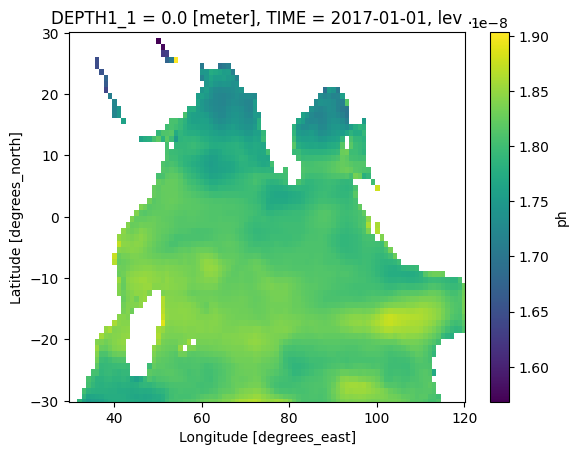

In [7]:
month_FF_ds2.isel(month=1).ph.plot()

# seasonal cycle

In [8]:
# annual_ds1 = month_hist_ds1.mean('month')
# annual_ds2 = month_FF_ds1.mean('month')
annual_ds3 = month_hist_ds2.mean('month')
annual_ds4 = month_FF_ds2.mean('month')


# seasonal_hist_ds1 = month_hist_ds1 - annual_ds1
# seasonal_FF_ds1 = month_FF_ds1 - annual_ds2
seasonal_hist_ds2 = month_hist_ds2 - annual_ds3
seasonal_FF_ds2 = month_FF_ds2 - annual_ds4

In [9]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

# as_hist_seasonal_ds1  = seasonal_hist_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# bob_hist_seasonal_ds1  = seasonal_hist_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
# cio_hist_seasonal_ds1  = seasonal_hist_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
# sio_hist_seasonal_ds1  = seasonal_hist_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

# as_FF_seasonal_ds1  = seasonal_FF_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# bob_FF_seasonal_ds1  = seasonal_FF_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
# cio_FF_seasonal_ds1  = seasonal_FF_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
# sio_FF_seasonal_ds1  = seasonal_FF_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_hist_seasonal_ds2  = seasonal_hist_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_hist_seasonal_ds2  = seasonal_hist_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_hist_seasonal_ds2  = seasonal_hist_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_hist_seasonal_ds2  = seasonal_hist_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_FF_seasonal_ds2  = seasonal_FF_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_FF_seasonal_ds2  = seasonal_FF_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_FF_seasonal_ds2  = seasonal_FF_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_FF_seasonal_ds2  = seasonal_FF_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])


In [7]:
# as_hist_seasonal_ds2.to_netcdf('as_hist_seasonal_H+_ssp585.nc')

In [8]:
# as_FF_seasonal_ds2.to_netcdf('as_FF_seasonal_H+_ssp585.nc')

In [9]:
as_hist_seasonal_ds2

<xarray.Dataset> Size: 216B
Dimensions:   (month: 12)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    ph        (month) float64 96B -2.24e-10 -2.614e-10 ... 9.044e-11 -6.47e-11

In [10]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

# as_hist_ds1  = month_hist_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# bob_hist_ds1  = month_hist_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
# cio_hist_ds1  = month_hist_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
# sio_hist_ds1  = month_hist_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

# as_FF_ds1  = month_FF_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# bob_FF_ds1  = month_FF_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
# cio_FF_ds1  = month_FF_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
# sio_FF_ds1  = month_FF_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_hist_ds2  = month_hist_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_hist_ds2  = month_hist_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_hist_ds2  = month_hist_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_hist_ds2  = month_hist_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_FF_ds2  = month_FF_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_FF_ds2  = month_FF_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_FF_ds2  = month_FF_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_FF_ds2  = month_FF_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])


In [11]:
as_hist_ds2.ph.values

array([8.53673371e-09, 8.50051355e-09, 8.55368949e-09, 8.71294342e-09,
       8.71387101e-09, 8.61175183e-09, 8.73295738e-09, 8.91281475e-09,
       8.80073124e-09, 8.66125420e-09, 8.59273611e-09, 8.56381993e-09])

In [12]:
# as_hist_ds1_max  = as_hist_ds1.ph.max(dim='month')
# as_FF_ds1_max  = as_FF_ds1.ph.max(dim='month')
as_hist_ds2_max  = as_hist_ds2.ph.max(dim='month')
as_FF_ds2_max  = as_FF_ds2.ph.max(dim='month')

# bob_hist_ds1_max  = bob_hist_ds1.ph.max(dim='month')
# bob_FF_ds1_max  = bob_FF_ds1.ph.max(dim='month')
bob_hist_ds2_max  = bob_hist_ds2.ph.max(dim='month')
bob_FF_ds2_max  = bob_FF_ds2.ph.max(dim='month')

# cio_hist_ds1_max  = cio_hist_ds1.ph.max(dim='month')
# cio_FF_ds1_max  = cio_FF_ds1.ph.max(dim='month')
cio_hist_ds2_max  = cio_hist_ds2.ph.max(dim='month')
cio_FF_ds2_max  = cio_FF_ds2.ph.max(dim='month')

# sio_hist_ds1_max  = sio_hist_ds1.ph.max(dim='month')
# sio_FF_ds1_max  = sio_FF_ds1.ph.max(dim='month')
sio_hist_ds2_max  = sio_hist_ds2.ph.max(dim='month')
sio_FF_ds2_max  = sio_FF_ds2.ph.max(dim='month')


In [13]:
# as_hist_ds1_max = as_hist_ds1_max * 10**(9)
# as_FF_ds1_max = as_FF_ds1_max * 10**(9)
as_hist_ds2_max = as_hist_ds2_max * 10**(9)
as_FF_ds2_max = as_FF_ds2_max * 10**(9)




# bob_hist_ds1_max = bob_hist_ds1_max * 10**(9)
# bob_FF_ds1_max = bob_FF_ds1_max * 10**(9)
bob_hist_ds2_max = bob_hist_ds2_max * 10**(9)
bob_FF_ds2_max = bob_FF_ds2_max * 10**(9)

# cio_hist_ds1_max = cio_hist_ds1_max * 10**(9)
# cio_FF_ds1_max = cio_FF_ds1_max * 10**(9)
cio_hist_ds2_max = cio_hist_ds2_max * 10**(9)
cio_FF_ds2_max = cio_FF_ds2_max * 10**(9)

# sio_hist_ds1_max = sio_hist_ds1_max * 10**(9)
# sio_FF_ds1_max = sio_FF_ds1_max * 10**(9)
sio_hist_ds2_max = sio_hist_ds2_max * 10**(9)
sio_FF_ds2_max = sio_FF_ds2_max * 10**(9)


In [14]:
sio_FF_ds2_max

<xarray.DataArray 'ph' ()> Size: 8B
array(18.56951342)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [22]:
sio_hist_ds2_max



<xarray.DataArray 'ph' ()> Size: 8B
array(8.24477306)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [17]:
as_FF_ds2_max

<xarray.DataArray 'ph' ()> Size: 8B
array(10.71679094)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058

In [343]:
as_hist_ds2_max

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 8.854

In [344]:
as_FF_ds2_max

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 18.32

In [23]:
# as_hist_ds1_min  = as_hist_ds1.ph.min(dim='month')
# as_FF_ds1_min  = as_FF_ds1.ph.min(dim='month')
as_hist_ds2_min  = as_hist_ds2.ph.min(dim='month')
as_FF_ds2_min  = as_FF_ds2.ph.min(dim='month')

# bob_hist_ds1_min  = bob_hist_ds1.ph.min(dim='month')
# bob_FF_ds1_min  = bob_FF_ds1.ph.min(dim='month')
bob_hist_ds2_min  = bob_hist_ds2.ph.min(dim='month')
bob_FF_ds2_min  = bob_FF_ds2.ph.min(dim='month')

# cio_hist_ds1_min  = cio_hist_ds1.ph.min(dim='month')
# cio_FF_ds1_min  = cio_FF_ds1.ph.min(dim='month')
cio_hist_ds2_min  = cio_hist_ds2.ph.min(dim='month')
cio_FF_ds2_min  = cio_FF_ds2.ph.min(dim='month')

# sio_hist_ds1_min  = sio_hist_ds1.ph.min(dim='month')
# sio_FF_ds1_min  = sio_FF_ds1.ph.min(dim='month')
sio_hist_ds2_min  = sio_hist_ds2.ph.min(dim='month')
sio_FF_ds2_min  = sio_FF_ds2.ph.min(dim='month')

In [24]:
as_hist_ds2_min

<xarray.DataArray 'ph' ()> Size: 8B
array(8.51628149e-09)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [26]:
cio_FF_ds2_min  

<xarray.DataArray 'ph' ()> Size: 8B
array(1.78219192e-08)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [348]:
cio_hist_ds2_min

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 8.276e-09

In [349]:
cio_FF_ds2_min

<xarray.Dataset> Size: 32B
Dimensions:   ()
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058
Data variables:
    ph        float64 8B 1.769e-08

In [27]:
# as_hist_ds1_min = as_hist_ds1_min * 10**(9)
# as_FF_ds1_min = as_FF_ds1_min * 10**(9)
as_hist_ds2_min = as_hist_ds2_min * 10**(9)
as_FF_ds2_min = as_FF_ds2_min * 10**(9)

# bob_hist_ds1_min = bob_hist_ds1_min * 10**(9)
# bob_FF_ds1_min = bob_FF_ds1_min * 10**(9)
bob_hist_ds2_min = bob_hist_ds2_min * 10**(9)
bob_FF_ds2_min = bob_FF_ds2_min * 10**(9)

# cio_hist_ds1_min = cio_hist_ds1_min * 10**(9)
# cio_FF_ds1_min = cio_FF_ds1_min * 10**(9)
cio_hist_ds2_min = cio_hist_ds2_min * 10**(9)
cio_FF_ds2_min = cio_FF_ds2_min * 10**(9)

# sio_hist_ds1_min = sio_hist_ds1_min * 10**(9)
# sio_FF_ds1_min = sio_FF_ds1_min * 10**(9)
sio_hist_ds2_min = sio_hist_ds2_min * 10**(9)
sio_FF_ds2_min = sio_FF_ds2_min * 10**(9)


In [29]:
sio_FF_ds2_min

<xarray.DataArray 'ph' ()> Size: 8B
array(9.19999033)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058

In [33]:
sio_hist_ds2_min

<xarray.DataArray 'ph' ()> Size: 8B
array(7.51123713)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058

In [28]:
sio_bem_hist_amp =sio_hist_ds2_max-sio_hist_ds2_min
sio_bem_FF_amp = sio_FF_ds2_max-sio_FF_ds2_min


# cio_cmip6_hist_amp = 8.08-8.06
# cio_cmip6_FF_amp = 7.75-7.73

cio_bem_hist_amp = cio_hist_ds2_max-cio_hist_ds2_min
cio_bem_FF_amp = cio_FF_ds2_max-cio_FF_ds2_min

# bob_cmip6_hist_amp = 8.08-8.05
# bob_cmip6_FF_amp = 7.75-7.72

bob_bem_hist_amp = bob_hist_ds2_max-bob_hist_ds2_min
bob_bem_FF_amp = bob_FF_ds2_max-bob_FF_ds2_min

# as_cmip6_hist_amp = 8.08-8.05
# as_cmip6_FF_amp = 7.76-7.73

as_bem_hist_amp = as_hist_ds2_max-as_hist_ds2_min
as_bem_FF_amp = as_FF_ds2_max-as_FF_ds2_min


In [47]:
as_bem_hist_amp

<xarray.DataArray 'ph' ()> Size: 8B
array(0.3254028)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [39]:
# sio_cmip6_amp = sio_cmip6_FF_amp - sio_cmip6_hist_amp
sio_bem_amp = sio_bem_FF_amp - sio_bem_hist_amp

# cio_cmip6_amp = cio_cmip6_FF_amp - cio_cmip6_hist_amp
cio_bem_amp = cio_bem_FF_amp - cio_bem_hist_amp

# bob_cmip6_amp = bob_cmip6_FF_amp - bob_cmip6_hist_amp
bob_bem_amp = bob_bem_FF_amp - bob_bem_hist_amp

# as_cmip6_amp = as_cmip6_FF_amp - as_cmip6_hist_amp
as_bem_amp = as_bem_FF_amp - as_bem_hist_amp

In [43]:
as_bem_amp

<xarray.DataArray 'ph' ()> Size: 8B
array(0.32678914)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [57]:
round(1.085074, 2)

1.09

In [353]:
# sio_cmip6_hist_amp = 8.54 - 7.53
# sio_cmip6_FF_amp = 18.85-17.08 

# sio_bem_hist_amp = 8.25-7.50
# sio_bem_FF_amp = 18.55- 16.88


# cio_cmip6_hist_amp = 8.80-8.32
# cio_cmip6_FF_amp = 18.59-17.81

# cio_bem_hist_amp = 8.59-8.27
# cio_bem_FF_amp = 18.21-17.69

# bob_cmip6_hist_amp = 8.89-8.31
# bob_cmip6_FF_amp = 19.08-17.75

# bob_bem_hist_amp = 8.68-8.32
# bob_bem_FF_amp = 18.70-17.8

# as_cmip6_hist_amp = 8.96-8.37
# as_cmip6_FF_amp = 18.58-17.33

# as_bem_hist_amp = 8.85-8.52
# as_bem_FF_amp = 18.32-17.63

In [354]:
# # sio_cmip6_amp = sio_cmip6_FF_amp - sio_cmip6_hist_amp
# sio_bem_amp = sio_bem_FF_amp - sio_bem_hist_amp

# cio_cmip6_amp = cio_cmip6_FF_amp - cio_cmip6_hist_amp
# cio_bem_amp = cio_bem_FF_amp - cio_bem_hist_amp

# bob_cmip6_amp = bob_cmip6_FF_amp - bob_cmip6_hist_amp
# bob_bem_amp = bob_bem_FF_amp - bob_bem_hist_amp

# as_cmip6_amp = as_cmip6_FF_amp - as_cmip6_hist_amp
# as_bem_amp = as_bem_FF_amp - as_bem_hist_amp



# sio_cmip6_amp = 0.76
# sio_bem_amp = 0.92

# cio_cmip6_amp = 0.30
# cio_bem_amp = 0.20

# bob_cmip6_amp = 0.74
# bob_bem_amp = 0.53

# as_cmip6_amp = 0.66
# as_bem_amp = 0.36

In [355]:
sio_cmip6_amp

0.76

In [356]:
sio_bem_amp 

0.92

In [357]:
as_bem_amp

0.36

In [358]:
as_cmip6_amp

0.66

In [359]:
bob_cmip6_amp

0.74

In [360]:
bob_bem_amp

0.53

In [361]:
cio_cmip6_amp

0.3

In [362]:
cio_bem_amp

0.2

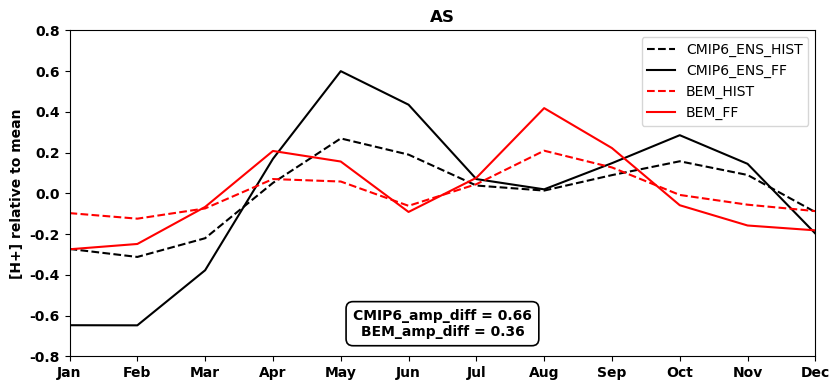

In [326]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# as_hist_seasonal_ds1 = as_hist_seasonal_ds1['ph']
# as_FF_seasonal_ds1 = as_FF_seasonal_ds1['ph']
# as_hist_seasonal_ds2 = as_hist_seasonal_ds2['ph']
# as_FF_seasonal_ds2 = as_FF_seasonal_ds2['ph']


# as_hist_seasonal_ds1 = as_hist_seasonal_ds1 * 10**(9)
# as_FF_seasonal_ds1 = as_FF_seasonal_ds1 * 10**(9)
# as_hist_seasonal_ds2 = as_hist_seasonal_ds2 * 10**(9)
# as_FF_seasonal_ds2 = as_FF_seasonal_ds2 * 10**(9)



# Dummy example values if not already defined
# Replace these with your actual calculated values
# as_cmip6_amp = 0.012
# as_bem_amp = 0.007

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot setup
plt.figure(figsize=(8.5, 4))

# Plot seasonal cycles
plt.plot(months, as_hist_seasonal_ds1, '--', label='CMIP6_ENS_HIST', color='black')
plt.plot(months, as_FF_seasonal_ds1, '-', label='CMIP6_ENS_FF', color='black')
plt.plot(months, as_hist_seasonal_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, as_FF_seasonal_ds2, '-', label='BEM_FF', color='red')

# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [-0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8]
plt.yticks(ticks=yticks, labels=[f'{y:.1f}' for y in yticks], fontsize=10, fontweight='bold')
plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('[H+] relative to mean', fontweight='bold')
plt.title('AS', fontweight='bold')
plt.legend()

# Add a box at the center with the amplitude difference values
amp_text = f'CMIP6_amp_diff = {as_cmip6_amp:.2f}\nBEM_amp_diff = {as_bem_amp:.2f}'
box_props = dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1.2)
plt.text(0.5, 0.1, amp_text, transform=plt.gca().transAxes, fontsize=10, 
         fontweight='bold', va='center', ha='center', bbox=box_props)
plt.tight_layout()
plt.savefig('seasonal_cycle_AS_H+_amp.png', bbox_inches='tight', dpi=600)
plt.show()


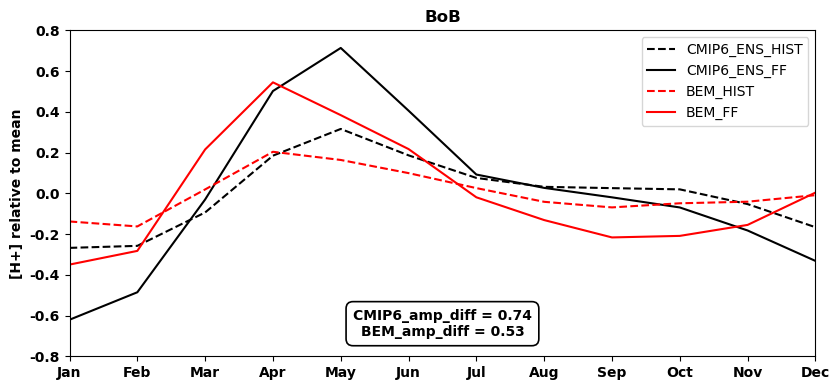

In [325]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# bob_hist_seasonal_ds1 = bob_hist_seasonal_ds1['ph']
# bob_FF_seasonal_ds1 = bob_FF_seasonal_ds1['ph']
# bob_hist_seasonal_ds2 = bob_hist_seasonal_ds2['ph']
# bob_FF_seasonal_ds2 = bob_FF_seasonal_ds2['ph']

# bob_hist_seasonal_ds1 = bob_hist_seasonal_ds1 * 10**(9)
# bob_FF_seasonal_ds1 = bob_FF_seasonal_ds1 * 10**(9)
# bob_hist_seasonal_ds2 = bob_hist_seasonal_ds2 * 10**(9)
# bob_FF_seasonal_ds2 = bob_FF_seasonal_ds2 * 10**(9)

# Time axis: 0 to 11 months

months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# djf_months = [11, 0, 1]   # Dec, Jan, Feb
# jas_months = [3, 4, 5]    # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8.5, 4))

# Highlight DJF months (min season)
# for wm in jas_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == jas_months[0] else "")

# # Highlight JJA months (max season)
# for sm in djf_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == djf_months[0] else "")

# Plot seasonal cycles
plt.plot(months, bob_hist_seasonal_ds1, '--', label='CMIP6_ENS_HIST', color='black')
plt.plot(months, bob_FF_seasonal_ds1, '-', label='CMIP6_ENS_FF', color='black')
plt.plot(months, bob_hist_seasonal_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, bob_FF_seasonal_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [-0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8]
plt.yticks(ticks=yticks, labels=[f'{y:.1f}' for y in yticks], fontsize=10, fontweight='bold')
plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('[H+] relative to mean', fontweight='bold')
plt.title('BoB', fontweight='bold')
plt.legend()

amp_text = f'CMIP6_amp_diff = {bob_cmip6_amp:.2f}\nBEM_amp_diff = {bob_bem_amp:.2f}'
box_props = dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1.2)
plt.text(0.5, 0.1, amp_text, transform=plt.gca().transAxes, fontsize=10, 
         fontweight='bold', va='center', ha='center', bbox=box_props)

plt.tight_layout()
plt.savefig('seasonal_cycle_BoB_H+_amp.png', bbox_inches = 'tight', dpi = 600)

plt.show()


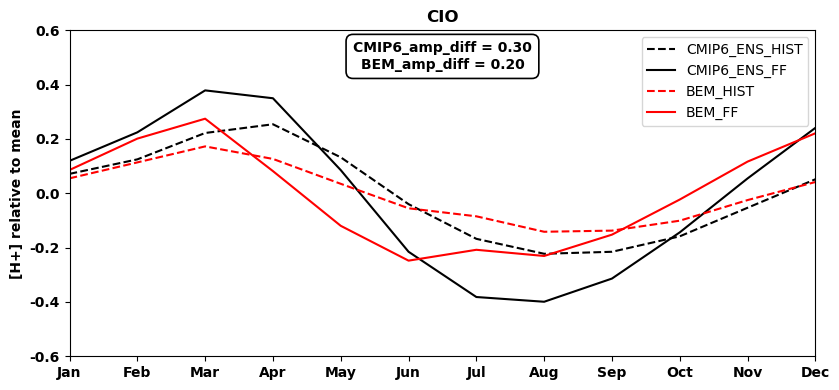

In [369]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# cio_hist_seasonal_ds1 = cio_hist_seasonal_ds1['ph']
# cio_FF_seasonal_ds1 = cio_FF_seasonal_ds1['ph']
# cio_hist_seasonal_ds2 = cio_hist_seasonal_ds2['ph']
# cio_FF_seasonal_ds2 = cio_FF_seasonal_ds2['ph']

# cio_hist_seasonal_ds1 = cio_hist_seasonal_ds1 * 10**(9)
# cio_FF_seasonal_ds1 = cio_FF_seasonal_ds1 * 10**(9)
# cio_hist_seasonal_ds2 = cio_hist_seasonal_ds2 * 10**(9)
# cio_FF_seasonal_ds2 = cio_FF_seasonal_ds2 * 10**(9)

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# fma_months = [1, 2, 3]   # Dec, Jan, Feb
# jas_months = [6, 7, 8]     # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8.5, 4))

# Highlight DJF months (min season)
# for wm in fma_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == fma_months[0] else "")

# # Highlight JJA months (max season)
# for sm in jas_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == jas_months[0] else "")

# # Plot seasonal cycles
plt.plot(months, cio_hist_seasonal_ds1, '--', label='CMIP6_ENS_HIST', color='black')
plt.plot(months, cio_FF_seasonal_ds1, '-', label='CMIP6_ENS_FF', color='black')
plt.plot(months, cio_hist_seasonal_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, cio_FF_seasonal_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6]
plt.yticks(ticks=yticks, labels=[f'{y:.1f}' for y in yticks], fontsize=10, fontweight='bold')
plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('[H+] relative to mean', fontweight='bold')
plt.title('CIO', fontweight='bold')
plt.legend()

amp_text = f'CMIP6_amp_diff = {cio_cmip6_amp:.2f}\nBEM_amp_diff = {cio_bem_amp:.2f}'
box_props = dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1.2)
plt.text(0.5, 0.92, amp_text, transform=plt.gca().transAxes, fontsize=10, 
         fontweight='bold', va='center', ha='center', bbox=box_props)


plt.tight_layout()
plt.savefig('seasonal_cycle_CIO_H+_amp.png', bbox_inches = 'tight', dpi = 600)

plt.show()


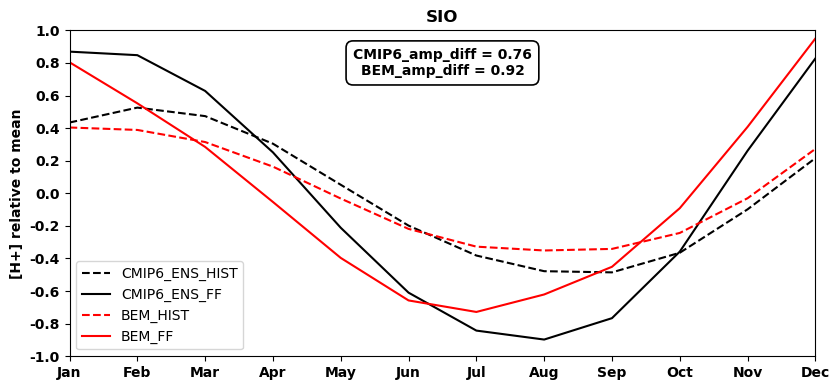

In [371]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# sio_hist_seasonal_ds1 = sio_hist_seasonal_ds1['ph']
# sio_FF_seasonal_ds1 = sio_FF_seasonal_ds1['ph']
# sio_hist_seasonal_ds2 = sio_hist_seasonal_ds2['ph']
# sio_FF_seasonal_ds2 = sio_FF_seasonal_ds2['ph']

# sio_hist_seasonal_ds1 = sio_hist_seasonal_ds1 * 10**(9)
# sio_FF_seasonal_ds1 = sio_FF_seasonal_ds1 * 10**(9)
# sio_hist_seasonal_ds2 = sio_hist_seasonal_ds2 * 10**(9)
# sio_FF_seasonal_ds2 = sio_FF_seasonal_ds2 * 10**(9)

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# djf_months = [11, 0, 1]   # Dec, Jan, Feb
# jas_months = [6, 7, 8]    # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8.5, 4))

# Highlight DJF months (min season)
# for wm in djf_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == djf_months[0] else "")

# # Highlight JJA months (max season)
# for sm in jas_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == jas_months[0] else "")

# Plot seasonal cycles
plt.plot(months, sio_hist_seasonal_ds1, '--', label='CMIP6_ENS_HIST', color='black')
plt.plot(months, sio_FF_seasonal_ds1, '-', label='CMIP6_ENS_FF', color='black')
plt.plot(months, sio_hist_seasonal_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, sio_FF_seasonal_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [-1.00, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.00]
plt.yticks(ticks=yticks, labels=[f'{y:.1f}' for y in yticks], fontsize=10, fontweight='bold')
plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('[H+] relative to mean', fontweight='bold')
plt.title('SIO', fontweight='bold')
plt.legend()

amp_text = f'CMIP6_amp_diff = {sio_cmip6_amp:.2f}\nBEM_amp_diff = {sio_bem_amp:.2f}'
box_props = dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1.2)
plt.text(0.5, 0.9, amp_text, transform=plt.gca().transAxes, fontsize=10, 
         fontweight='bold', va='center', ha='center', bbox=box_props)

plt.tight_layout()
plt.savefig('seasonal_cycle_SIO_H+_amp.png', bbox_inches = 'tight', dpi = 600)

plt.show()


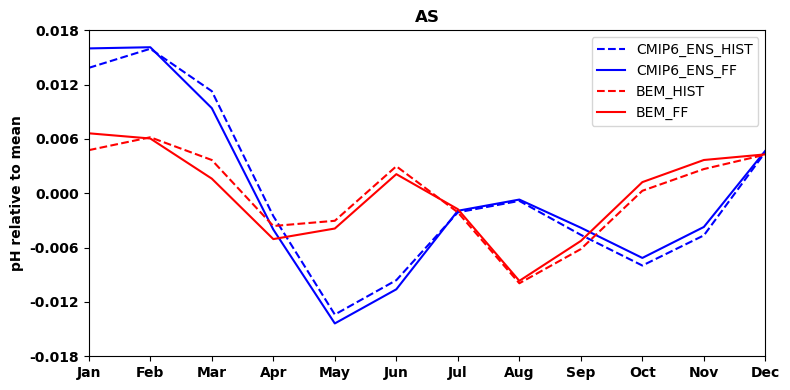

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# as_hist_ds1 = as_hist_ds1['ph']
# as_FF_ds1 = as_FF_ds1['ph']
# as_hist_ds2 = as_hist_ds2['ph']
# as_FF_ds2 = as_FF_ds2['ph']

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# djf_months = [11, 0, 1]   # Dec, Jan, Feb
# jas_months = [6, 7, 8]    # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8, 4))

# Highlight DJF months (min season)
# for wm in jas_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == jas_months[0] else "")

# # Highlight JJA months (max season)
# for sm in djf_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == djf_months[0] else "")

# Plot seasonal cycles
plt.plot(months, as_hist_ds1, '--', label='CMIP6_ENS_HIST', color='blue')
plt.plot(months, as_FF_ds1, '-', label='CMIP6_ENS_FF', color='blue')
plt.plot(months, as_hist_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, as_FF_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [0.018, 0.012, 0.006, 0, -0.006, -0.012, -0.018]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=10, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('pH relative to mean', fontweight='bold')
plt.title('AS', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('seasonal_cycle_AS_amp.png', bbox_inches = 'tight', dpi = 600)

plt.show()


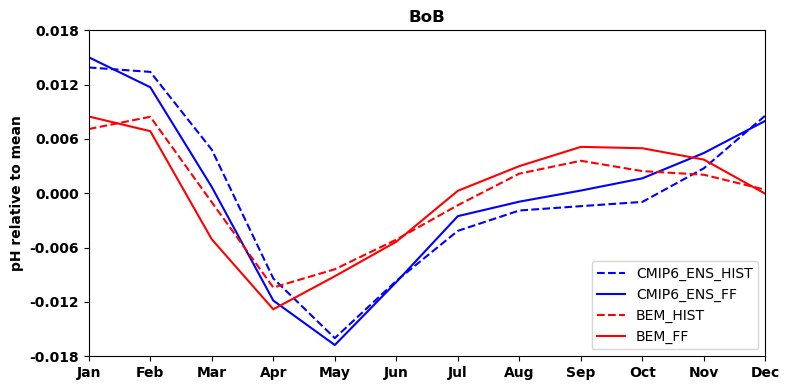

In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

bob_hist_ds1 = bob_hist_ds1['ph']
bob_FF_ds1 = bob_FF_ds1['ph']
bob_hist_ds2 = bob_hist_ds2['ph']
bob_FF_ds2 = bob_FF_ds2['ph']

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# djf_months = [11, 0, 1]   # Dec, Jan, Feb
# jas_months = [3, 4, 5]    # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8, 4))

# Highlight DJF months (min season)
# for wm in jas_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == jas_months[0] else "")

# # Highlight JJA months (max season)
# for sm in djf_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == djf_months[0] else "")

# Plot seasonal cycles
plt.plot(months, bob_hist_ds1, '--', label='CMIP6_ENS_HIST', color='blue')
plt.plot(months, bob_FF_ds1, '-', label='CMIP6_ENS_FF', color='blue')
plt.plot(months, bob_hist_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, bob_FF_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [0.018, 0.012, 0.006, 0, -0.006, -0.012, -0.018]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=10, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('pH relative to mean', fontweight='bold')
plt.title('BoB', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('seasonal_cycle_BoB.png', bbox_inches = 'tight', dpi = 600)

plt.show()


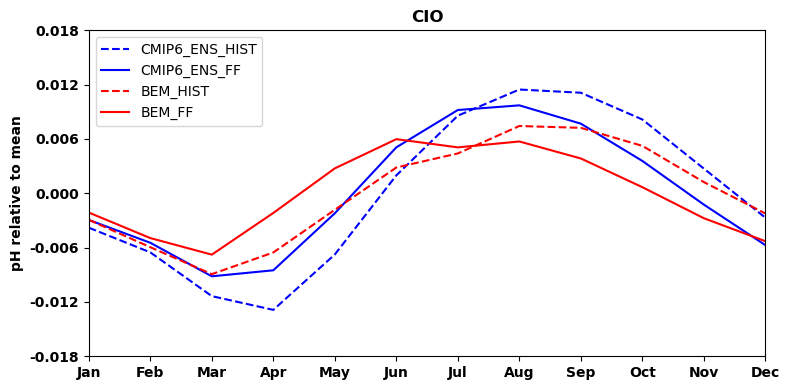

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

cio_hist_ds1 = cio_hist_ds1['ph']
cio_FF_ds1 = cio_FF_ds1['ph']
cio_hist_ds2 = cio_hist_ds2['ph']
cio_FF_ds2 = cio_FF_ds2['ph']

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# fma_months = [1, 2, 3]   # Dec, Jan, Feb
# jas_months = [6, 7, 8]     # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8, 4))

# Highlight DJF months (min season)
# for wm in fma_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == fma_months[0] else "")

# # Highlight JJA months (max season)
# for sm in jas_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == jas_months[0] else "")

# # Plot seasonal cycles
plt.plot(months, cio_hist_ds1, '--', label='CMIP6_ENS_HIST', color='blue')
plt.plot(months, cio_FF_ds1, '-', label='CMIP6_ENS_FF', color='blue')
plt.plot(months, cio_hist_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, cio_FF_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [0.018, 0.012, 0.006, 0, -0.006, -0.012, -0.018]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=10, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('pH relative to mean', fontweight='bold')
plt.title('CIO', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('seasonal_cycle_CIO.png', bbox_inches = 'tight', dpi = 600)

plt.show()


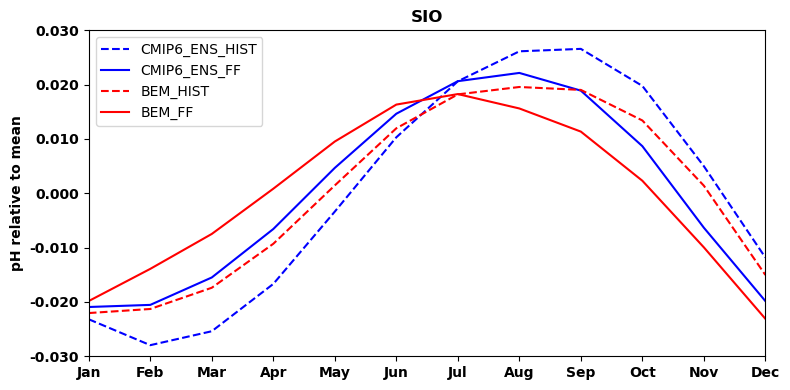

In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sio_hist_ds1 = sio_hist_ds1['ph']
sio_FF_ds1 = sio_FF_ds1['ph']
sio_hist_ds2 = sio_hist_ds2['ph']
sio_FF_ds2 = sio_FF_ds2['ph']

# Time axis: 0 to 11 months
months = np.arange(12)

# Define X-tick positions and labels
xtick_locs = np.arange(12)
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed seasonal months
# djf_months = [11, 0, 1]   # Dec, Jan, Feb
# jas_months = [6, 7, 8]    # Jul, Aug, Sep

# Plot setup
plt.figure(figsize=(8, 4))

# Highlight DJF months (min season)
# for wm in djf_months:
#     plt.axvspan(wm - 0.5, wm + 0.5, color='lightgray', alpha=0.6, label='Min' if wm == djf_months[0] else "")

# # Highlight JJA months (max season)
# for sm in jas_months:
#     plt.axvspan(sm - 0.5, sm + 0.5, color='lightcoral', alpha=0.3, label='Max' if sm == jas_months[0] else "")

# Plot seasonal cycles
plt.plot(months, sio_hist_ds1, '--', label='CMIP6_ENS_HIST', color='blue')
plt.plot(months, sio_FF_ds1, '-', label='CMIP6_ENS_FF', color='blue')
plt.plot(months, sio_hist_ds2, '--', label='BEM_HIST', color='red')
plt.plot(months, sio_FF_ds2, '-', label='BEM_FF', color='red')


# Axis formatting
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=10, fontweight='bold')
yticks = [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=10, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('pH relative to mean', fontweight='bold')
plt.title('SIO', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('seasonal_cycle_SIO.png', bbox_inches = 'tight', dpi = 600)

plt.show()
